
# Overview: Transfer of aging-age prediction models to sagittal and hippocampus datasets

This notebook adapts the **data-loading / path-management style** used in `AgingBrain_training_analysis` and combines it with the **transfer-analysis logic** from `AgingMousebrain_Part0_modeltraining`.

## Summary
This notebook:
1. loads the trained SpiderNet run from the aging mouse brain training dataset,
2. loads or refits the cell-type-specific age-prediction regressors used downstream,
3. preprocesses the **sagittal** and **hippocampus** transfer datasets,
4. infers transfer-dataset meta-interactions with the trained SpiderNet model,
5. predicts cell-level age using both **SpiderNet aggregated MI features** and the **PCA baseline**,
6. summarizes **old / young predicted-age ratios** for each cell type,
7. and saves the main tables and plots into the corresponding transfer run directories.

Compared with the older notebook, the code here keeps the same overall analysis logic but reduces duplicated blocks and makes the train / transfer path handling more explicit.


## 0. Dataset setup (edit this cell first)

Set the training run, the processed-data bundles generated by the new transfer preprocessing notebook, and the output roots for the sagittal and hippocampus transfer analyses here.

In [1]:
from pathlib import Path

# =========================================================
# Training run used as the source model
# =========================================================
TRAIN_DATA_ROOT = Path("D:/SpiderNet/Data/AgingBrain")
TRAIN_OUTPUT_ROOT = Path("D:/SpiderNet/Results/AgingBrain")
TRAIN_PROCESSED_DATA_DIR = Path("D:/SpiderNet/Results/AgingBrain/ProcessedData")

# =========================================================
# Transfer datasets
# =========================================================
SAGITTAL_DATA_ROOT = Path("D:/SpiderNet/Data/AgingBrain/AgingBrain_Sagittal")
SAGITTAL_OUTPUT_ROOT = Path("D:/SpiderNet/Results/AgingBrain/AgingBrain_Sagittal")
SAGITTAL_PROCESSED_DATA_DIR = Path("D:/SpiderNet/Results/AgingBrain/AgingBrain_Sagittal/ProcessedData")

HIPPOCAMPUS_DATA_ROOT = Path("D:/SpiderNet/Data/AgingBrain/AgingBrain_Hippocampus")
HIPPOCAMPUS_OUTPUT_ROOT = Path("D:/SpiderNet/Results/AgingBrain/AgingBrain_Hippocampus")
HIPPOCAMPUS_PROCESSED_DATA_DIR = Path("D:/SpiderNet/Results/AgingBrain/AgingBrain_Hippocampus/ProcessedData")

# =========================================================
# Baseline feature locations
# COMMOT is available for Coronal + Hippocampus, but not Sagittal.
# Banksy is available for Coronal + Sagittal + Hippocampus.
# =========================================================
BANKSY_SUBDIR = "Banksy"
COMMOT_SUBDIR = "COMMOT"
BANKSY_LAMBDA_CELLIDENTITY = 0.2

DATASET_FEATURE_CONFIG = {
    "Coronal": {
        "output_root": TRAIN_OUTPUT_ROOT,
        "filename_hint": "coronal",
        "has_banksy": True,
        "has_commot": True,
    },
    "Sagittal": {
        "output_root": SAGITTAL_OUTPUT_ROOT,
        "filename_hint": "sagittal",
        "has_banksy": True,
        "has_commot": False,
    },
    "Hippocampus": {
        "output_root": HIPPOCAMPUS_OUTPUT_ROOT,
        "filename_hint": "hippocampus",
        "has_banksy": True,
        "has_commot": True,
    },
}

PREFERRED_METHOD_ORDER = ["SpiderNet", "PCA", "Banksy", "COMMOT"]
METHOD_COLOR_DICT = {
    "SpiderNet": "#e72625",
    "PCA": "#65c3cf",
    "Banksy": "#378040",
    "COMMOT": "#b66ca1",
}

# =========================================================
# Shared dataset fields
# =========================================================
SPECIES = "mouse"
SAMPLE_ID_COL = "age"
CELL_TYPE_COL = "celltype"
SPATIAL_KEY = "spatial"

# =========================================================
# Preprocessing settings
# These should match the preprocessing notebook unless you have a
# strong reason to change them.
# =========================================================
N_HVG = 1000
N_HVG_LR = 2000
NUM_NEIGHBORS = 5

# These are kept only for compatibility with helper code below.
CC_PROP_THRESHOLD = 0.01
IF_SUBSET_LRPAIR = False
NUM_SUBSET_LRPAIR_RATIO = 0.80
IF_BOTH_DIRECTIONS = False

# =========================================================
# Model / training settings
# These should match the trained SpiderNet run.
# =========================================================
DIM_ENVIR = 30
N_JOBS = 5
MAX_EPOCH = 50000
VERSION = "V1"
HIDDEN_CHANNELS = 256

# Optional manual checkpoint override.
# Set to None to automatically use the latest model_epoch*.pth.
MODEL_CHECKPOINT = None

# =========================================================
# Transfer analysis settings
# =========================================================
REPROCESS_TRANSFER_DATA = False
REFIT_REGRESSORS_IF_MISSING = True
PCA_N_COMPONENTS = 20
OLD_AGE_THRESHOLD = 19


## 1. Imports and device setup

In [2]:
import copy
import json
import os
import pickle
import re
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.sparse as sp
import torch

from IPython.display import display
from scipy.io import mmread
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from torch_scatter import scatter_mean

from SpiderNet.config import *
from SpiderNet.io import load_processed_data, get_spidernet_pyg_list_path, load_spidernet_pyg_list, spidernet_pyg_list_exists
from SpiderNet.api import build_model, infer_meta_interactions, normalize_outputs, export_results

cuda_available = torch.cuda.is_available()
device = "cuda" if cuda_available else "cpu"
print(f"Using device: {device}")

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["mathtext.fontset"] = "dejavuserif"
plt.rcParams["font.family"] = "arial"
sns.set_theme(style="white", context="paper")

C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Using device: cuda


## 2. Build path configs

In [3]:

train_paths = PathConfig(
    data_root=TRAIN_DATA_ROOT,
    output_root=TRAIN_OUTPUT_ROOT,
    species=SPECIES,
    version=VERSION,
)

sagittal_paths = PathConfig(
    data_root=SAGITTAL_DATA_ROOT,
    output_root=SAGITTAL_OUTPUT_ROOT,
    species=SPECIES,
    version=VERSION,
)

hippocampus_paths = PathConfig(
    data_root=HIPPOCAMPUS_DATA_ROOT,
    output_root=HIPPOCAMPUS_OUTPUT_ROOT,
    species=SPECIES,
    version=VERSION,
)

preprocess_cfg = PreprocessConfig(
    n_hvg=N_HVG,
    n_hvg_lr=N_HVG_LR,
    num_neighbors=NUM_NEIGHBORS
)

train_cfg = TrainingConfig(
    dim_envir=DIM_ENVIR,
    n_jobs=N_JOBS,
    max_epoch=MAX_EPOCH,
    version=VERSION
)

train_run_dirs = train_paths.ensure_dirs(dim_envir=train_cfg.dim_envir)
sagittal_run_dirs = sagittal_paths.ensure_dirs(dim_envir=train_cfg.dim_envir)
hippocampus_run_dirs = hippocampus_paths.ensure_dirs(dim_envir=train_cfg.dim_envir)

display(pd.DataFrame([
    {"dataset": "train", "data_root": str(train_paths.data_root), "output_root": str(train_paths.output_root), "run_dir": str(train_run_dirs["run_dir"])},
    {"dataset": "sagittal", "data_root": str(sagittal_paths.data_root), "output_root": str(sagittal_paths.output_root), "run_dir": str(sagittal_run_dirs["run_dir"])},
    {"dataset": "hippocampus", "data_root": str(hippocampus_paths.data_root), "output_root": str(hippocampus_paths.output_root), "run_dir": str(hippocampus_run_dirs["run_dir"])},
]))


,dataset,data_root,output_root,run_dir
0,train,D:\SpiderNet\Data\AgingBrain,D:\SpiderNet\Results\AgingBrain,D:\SpiderNet\Results\AgingBrain\V1\SpiderNet_R...
1,sagittal,D:\SpiderNet\Data\AgingBrain\AgingBrain_Sagittal,D:\SpiderNet\Results\AgingBrain\AgingBrain_Sag...,D:\SpiderNet\Results\AgingBrain\AgingBrain_Sag...
2,hippocampus,D:\SpiderNet\Data\AgingBrain\AgingBrain_Hippoc...,D:\SpiderNet\Results\AgingBrain\AgingBrain_Hip...,D:\SpiderNet\Results\AgingBrain\AgingBrain_Hip...


### Quick path check

In [4]:
rows = [
    {"item": "TRAIN_DATA_ROOT", "value": str(TRAIN_DATA_ROOT), "exists": TRAIN_DATA_ROOT.exists()},
    {"item": "TRAIN_OUTPUT_ROOT", "value": str(TRAIN_OUTPUT_ROOT), "exists": TRAIN_OUTPUT_ROOT.exists()},
    {"item": "TRAIN_PROCESSED_DATA_DIR", "value": str(TRAIN_PROCESSED_DATA_DIR), "exists": TRAIN_PROCESSED_DATA_DIR.exists()},
    {"item": "SAGITTAL_DATA_ROOT", "value": str(SAGITTAL_DATA_ROOT), "exists": SAGITTAL_DATA_ROOT.exists()},
    {"item": "SAGITTAL_PROCESSED_DATA_DIR", "value": str(SAGITTAL_PROCESSED_DATA_DIR), "exists": SAGITTAL_PROCESSED_DATA_DIR.exists()},
    {"item": "HIPPOCAMPUS_DATA_ROOT", "value": str(HIPPOCAMPUS_DATA_ROOT), "exists": HIPPOCAMPUS_DATA_ROOT.exists()},
    {"item": "HIPPOCAMPUS_PROCESSED_DATA_DIR", "value": str(HIPPOCAMPUS_PROCESSED_DATA_DIR), "exists": HIPPOCAMPUS_PROCESSED_DATA_DIR.exists()},
    {"item": "Train CellChat DB", "value": str(train_paths.cellchat_db), "exists": Path(train_paths.cellchat_db).exists()},
    {"item": "Train scSeqComm DB", "value": str(train_paths.scseqcomm_db), "exists": Path(train_paths.scseqcomm_db).exists()},
]
display(pd.DataFrame(rows))


,item,value,exists
0,TRAIN_DATA_ROOT,D:\SpiderNet\Data\AgingBrain,True
1,TRAIN_OUTPUT_ROOT,D:\SpiderNet\Results\AgingBrain,True
2,TRAIN_PROCESSED_DATA_DIR,D:\SpiderNet\Results\AgingBrain\ProcessedData,True
3,SAGITTAL_DATA_ROOT,D:\SpiderNet\Data\AgingBrain\AgingBrain_Sagittal,True
4,SAGITTAL_PROCESSED_DATA_DIR,D:\SpiderNet\Results\AgingBrain\AgingBrain_Sag...,True
5,HIPPOCAMPUS_DATA_ROOT,D:\SpiderNet\Data\AgingBrain\AgingBrain_Hippoc...,True
6,HIPPOCAMPUS_PROCESSED_DATA_DIR,D:\SpiderNet\Results\AgingBrain\AgingBrain_Hip...,True
7,Train CellChat DB,D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\...,True
8,Train scSeqComm DB,D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\...,True


## 3. Load the training processed data and the trained SpiderNet checkpoint

In [5]:
processed_train = load_processed_data(TRAIN_PROCESSED_DATA_DIR)

print("Training processed directory:", TRAIN_PROCESSED_DATA_DIR)
print("Training batches:", len(processed_train.adata_list))
print("Training cells:", np.sum([adata.n_obs for adata in processed_train.adata_list]))
print("Training genes:", processed_train.genenames_train.shape[0])
print("Training LR pairs:", len(processed_train.lr_list))


Training processed directory: D:\SpiderNet\Results\AgingBrain\ProcessedData
Training batches: 10
Training cells: 712695
Training genes: 300
Training LR pairs: 85


In [6]:

def resolve_latest_checkpoint(model_dir, manual_checkpoint=None):
    if manual_checkpoint is not None:
        checkpoint_path = Path(manual_checkpoint)
        if not checkpoint_path.exists():
            raise FileNotFoundError(f"MODEL_CHECKPOINT does not exist: {checkpoint_path}")
        return checkpoint_path

    checkpoint_candidates = list(Path(model_dir).glob("model_epoch*.pth"))
    if len(checkpoint_candidates) == 0:
        raise FileNotFoundError(f"No checkpoint matching 'model_epoch*.pth' was found in: {model_dir}")

    def extract_epoch(path_obj):
        match = re.search(r"model_epoch(\d+)\.pth$", path_obj.name)
        return int(match.group(1)) if match else -1

    checkpoint_candidates = sorted(checkpoint_candidates, key=extract_epoch)
    return checkpoint_candidates[-1]


checkpoint_path = resolve_latest_checkpoint(train_run_dirs["model_dir"], MODEL_CHECKPOINT)
print("Checkpoint selected:", checkpoint_path)


Checkpoint selected: D:\SpiderNet\Results\AgingBrain\V1\SpiderNet_Result_dim30\Model\model_epoch49999.pth


In [7]:

model = build_model(
    processed=processed_train,
    train_cfg=train_cfg,
    device=device,
    hidden_channels=HIDDEN_CHANNELS,
)

state = torch.load(checkpoint_path, map_location=device)
if isinstance(state, dict) and "model_state_dict" in state:
    state = state["model_state_dict"]

model.load_state_dict(state)
model = model.to(device)
model.eval()

print("Model loaded and set to eval mode.")


Number of GPUs available: 1
GPU 0: NVIDIA GeForce RTX 4070
Model loaded and set to eval mode.


## 4. Helper functions

In [8]:
from SpiderNet.io import get_spidernet_pyg_list_path, load_spidernet_pyg_list, spidernet_pyg_list_exists
def load_pickle(path):
    with open(path, "rb") as handle:
        return pickle.load(handle)


def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as handle:
        pickle.dump(obj, handle)


def get_dense_gene_matrix(adata_list):
    matrices = []
    for adata in adata_list:
        X = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
        matrices.append(X)
    return np.vstack(matrices)


def get_obs_concat(processed, candidates, required=False):
    if isinstance(candidates, str):
        candidates = [candidates]

    for column in candidates:
        values = []
        ok = True
        for adata in processed.adata_list:
            if column not in adata.obs.columns:
                ok = False
                break
            values.append(np.asarray(adata.obs[column]))
        if ok:
            return np.hstack(values), column

    if required:
        raise KeyError(f"None of the candidate columns were found: {candidates}")
    return None, None


def get_single_obs_values(adata, candidates):
    values = []
    for column in candidates:
        if column not in adata.obs.columns:
            continue
        unique_values = pd.unique(adata.obs[column].astype(str))
        for value in unique_values:
            value = str(value).strip()
            if len(value) > 0 and value.lower() != "nan":
                values.append(value)
    seen = []
    for value in values:
        if value not in seen:
            seen.append(value)
    return seen


def format_numeric_token(value):
    try:
        value_float = float(value)
        if np.isfinite(value_float) and abs(value_float - round(value_float)) < 1e-8:
            return str(int(round(value_float)))
        return str(value_float)
    except Exception:
        return str(value)


def get_slice_identifier_candidates(adata):
    raw_values = get_single_obs_values(
        adata,
        ["age", "sample_name_full", "sample_name", "sample", "SAMPLE_ID"]
    )

    candidates = []
    for value in raw_values:
        value_str = str(value)
        candidates.append(value_str)
        candidates.append(format_numeric_token(value_str))
        candidates.append(value_str.replace(" ", "_"))
        candidates.append(value_str.replace("-", "_"))

    obs_name_hint = None
    if getattr(adata, "obs_names", None) is not None and len(adata.obs_names) > 0:
        obs_name_hint = str(adata.obs_names[0]).split("_")[0]
    if obs_name_hint:
        candidates.append(obs_name_hint)

    cleaned = []
    for value in candidates:
        value = str(value).strip()
        if len(value) == 0 or value.lower() == "nan":
            continue
        if value not in cleaned:
            cleaned.append(value)
    return cleaned


def aggregate_mi_features(factor_envir_list, spidernet_data_list, device):
    mi_sr_agg_all = []
    for factor_envir_cur, data_cur in zip(factor_envir_list, spidernet_data_list):
        factor_envir_cur = torch.tensor(factor_envir_cur, dtype=torch.float32, device=device)
        edge_index_cur = data_cur["edge_index"].to(device)
        num_cell_cur = data_cur.x.shape[0]

        mi_receiver_agg_cur = scatter_mean(
            factor_envir_cur,
            edge_index_cur[:, 1].to(torch.int64),
            dim=0,
            dim_size=num_cell_cur
        ).cpu().numpy()

        mi_sender_agg_cur = scatter_mean(
            factor_envir_cur,
            edge_index_cur[:, 0].to(torch.int64),
            dim=0,
            dim_size=num_cell_cur
        ).cpu().numpy()

        mi_sr_agg_cur = np.hstack([mi_sender_agg_cur, mi_receiver_agg_cur])
        mi_sr_agg_all.append(mi_sr_agg_cur)

    return np.vstack(mi_sr_agg_all)


def fit_celltype_regressors(X, celltype_all, y):
    regressors = {}
    unique_celltypes = np.sort(pd.unique(celltype_all))
    for celltype_cur in unique_celltypes:
        idx = np.where(celltype_all == celltype_cur)[0]
        if idx.shape[0] == 0:
            continue
        regressors[celltype_cur] = LinearRegression().fit(X[idx, :], y[idx])
    return regressors


def get_commot_pathway_keys(commot_adata):
    keys = list(commot_adata.obsp.keys())
    total_key = "commot-cellchat-total-total"
    pathway_keys = [
        k for k in keys
        if k.startswith("commot-cellchat-")
        and len(k.split("-")) == 3
        and k != total_key
    ]
    return sorted(pathway_keys)


def get_banksy_lambda_string(value):
    value_str = str(value)
    if "." in value_str:
        value_str = value_str.rstrip("0").rstrip(".")
    return value_str


def resolve_banksy_triplet_for_slice(adata, dataset_label, dataset_cfg):
    banksy_dir = Path(dataset_cfg["output_root"]) / BANKSY_SUBDIR
    if not banksy_dir.exists():
        raise FileNotFoundError(f"{dataset_label}: Banksy directory does not exist: {banksy_dir}")

    lambda_str = get_banksy_lambda_string(BANKSY_LAMBDA_CELLIDENTITY)
    filename_hint = dataset_cfg["filename_hint"]
    identifier_candidates = get_slice_identifier_candidates(adata)

    preferred_patterns = []
    for token in identifier_candidates:
        preferred_patterns.extend([
            f"aging_{filename_hint}_age{token}_Banksy_cellidentity_lambda{lambda_str}.mtx",
            f"aging_{filename_hint}_{token}_Banksy_cellidentity_lambda{lambda_str}.mtx",
            f"*{filename_hint}*{token}*Banksy_cellidentity_lambda{lambda_str}.mtx",
            f"*{token}*Banksy_cellidentity_lambda{lambda_str}.mtx",
        ])

    candidate_paths = []
    for pattern in preferred_patterns:
        candidate_paths.extend(sorted(banksy_dir.glob(pattern)))

    if len(candidate_paths) == 0:
        candidate_paths = sorted(banksy_dir.glob(f"*Banksy_cellidentity_lambda{lambda_str}.mtx"))

    candidate_paths_unique = []
    for path in candidate_paths:
        if path not in candidate_paths_unique:
            candidate_paths_unique.append(path)

    if len(candidate_paths_unique) == 0:
        raise FileNotFoundError(
            f"{dataset_label}: no Banksy matrix file was found in {banksy_dir} for identifiers {identifier_candidates}"
        )

    obs_index = pd.Index(adata.obs.index.astype(str))
    best_score = None
    best_triplet = None

    for mtx_path in candidate_paths_unique:
        genes_path = Path(str(mtx_path).replace(".mtx", "_genes.csv"))
        barcodes_path = Path(str(mtx_path).replace(".mtx", "_barcodes.csv"))
        if not genes_path.exists() or not barcodes_path.exists():
            continue

        barcodes_df = pd.read_csv(barcodes_path)
        barcode_col = "barcode" if "barcode" in barcodes_df.columns else barcodes_df.columns[0]
        barcodes = pd.Index(barcodes_df[barcode_col].astype(str))
        overlap = int(obs_index.isin(barcodes).sum())
        contains_hint = int(filename_hint.lower() in mtx_path.name.lower())
        token_hit = int(any(token.lower() in mtx_path.name.lower() for token in identifier_candidates))
        n_obs_match = int(len(barcodes) == adata.n_obs)
        score = (overlap, n_obs_match, token_hit, contains_hint)

        if (best_score is None) or (score > best_score):
            best_score = score
            best_triplet = (mtx_path, genes_path, barcodes_path)

    if best_triplet is None or best_score[0] == 0:
        raise FileNotFoundError(
            f"{dataset_label}: could not match a Banksy file to slice identifiers {identifier_candidates} in {banksy_dir}"
        )

    return best_triplet


def load_banksy_matrix_for_processed(processed_transfer, dataset_label, dataset_cfg):
    banksy_matrix_all = []

    for slice_index, adata_cur in enumerate(processed_transfer.adata_list):
        mtx_path, genes_path, barcodes_path = resolve_banksy_triplet_for_slice(
            adata=adata_cur,
            dataset_label=dataset_label,
            dataset_cfg=dataset_cfg,
        )

        print(f"{dataset_label}: matched Banksy slice {slice_index} -> {mtx_path.name}")

        mat = mmread(mtx_path).tocsr()
        genes_df = pd.read_csv(genes_path)
        barcodes_df = pd.read_csv(barcodes_path)

        gene_col = "gene" if "gene" in genes_df.columns else genes_df.columns[0]
        barcode_col = "barcode" if "barcode" in barcodes_df.columns else barcodes_df.columns[0]

        genes = genes_df[gene_col].astype(str).tolist()
        barcodes = barcodes_df[barcode_col].astype(str).tolist()

        banksy_matrix = pd.DataFrame.sparse.from_spmatrix(
            mat,
            index=genes,
            columns=barcodes,
        ).T
        banksy_matrix.index = banksy_matrix.index.astype(str)

        obs_index = pd.Index(adata_cur.obs.index.astype(str))
        missing_barcodes = obs_index.difference(banksy_matrix.index)
        if len(missing_barcodes) > 0:
            raise KeyError(
                f"{dataset_label}: {len(missing_barcodes)} cells are missing from the matched Banksy file "
                f"{mtx_path.name}. First few missing barcodes: {missing_barcodes[:5].tolist()}"
            )

        banksy_matrix_all.append(banksy_matrix.loc[obs_index, :])

    banksy_matrix_all = pd.concat(banksy_matrix_all, axis=0)
    banksy_matrix_all = banksy_matrix_all.sparse.to_dense() if hasattr(banksy_matrix_all, "sparse") else banksy_matrix_all
    return np.asarray(banksy_matrix_all, dtype=np.float32)


def fit_dataset_specific_banksy_pca(processed_transfer, dataset_label, dataset_cfg, n_components=20):
    banksy_matrix_all = load_banksy_matrix_for_processed(
        processed_transfer=processed_transfer,
        dataset_label=dataset_label,
        dataset_cfg=dataset_cfg,
    )
    pca_model = PCA(n_components=n_components)
    banksy_matrix_all_pca = pca_model.fit_transform(banksy_matrix_all)
    return banksy_matrix_all_pca, pca_model


def resolve_commot_file_for_slice(adata, dataset_label, dataset_cfg, allow_missing=False):
    commot_dir = Path(dataset_cfg["output_root"]) / COMMOT_SUBDIR
    if not commot_dir.exists():
        if allow_missing:
            return None
        raise FileNotFoundError(f"{dataset_label}: COMMOT directory does not exist: {commot_dir}")

    filename_hint = dataset_cfg["filename_hint"]
    identifier_candidates = get_slice_identifier_candidates(adata)

    preferred_patterns = []
    for token in identifier_candidates:
        preferred_patterns.extend([
            f"aging_{filename_hint}_age{token}_commot.h5ad",
            f"aging_{filename_hint}_{token}_commot.h5ad",
            f"*{filename_hint}*{token}*commot*.h5ad",
            f"*{token}*commot*.h5ad",
        ])

    candidate_paths = []
    for pattern in preferred_patterns:
        candidate_paths.extend(sorted(commot_dir.glob(pattern)))

    if len(candidate_paths) == 0:
        candidate_paths = sorted(commot_dir.glob("*commot*.h5ad"))

    candidate_paths_unique = []
    for path in candidate_paths:
        if path not in candidate_paths_unique:
            candidate_paths_unique.append(path)

    if len(candidate_paths_unique) == 0:
        if allow_missing:
            return None
        raise FileNotFoundError(
            f"{dataset_label}: no COMMOT file was found in {commot_dir} for identifiers {identifier_candidates}"
        )

    best_score = None
    best_path = None

    for commot_path in candidate_paths_unique:
        try:
            adata_commot = sc.read_h5ad(commot_path, backed="r")
            n_obs_commot = int(adata_commot.n_obs)
            obs_names_commot = pd.Index(adata_commot.obs_names.astype(str))
            try:
                adata_commot.file.close()
            except Exception:
                pass
        except Exception:
            adata_commot = sc.read_h5ad(commot_path)
            n_obs_commot = int(adata_commot.n_obs)
            obs_names_commot = pd.Index(adata_commot.obs_names.astype(str))

        obs_index = pd.Index(adata.obs.index.astype(str))
        overlap = int(obs_index.isin(obs_names_commot).sum())
        n_obs_match = int(n_obs_commot == adata.n_obs)
        contains_hint = int(filename_hint.lower() in commot_path.name.lower())
        token_hit = int(any(token.lower() in commot_path.name.lower() for token in identifier_candidates))
        score = (overlap, n_obs_match, token_hit, contains_hint)

        if (best_score is None) or (score > best_score):
            best_score = score
            best_path = commot_path

    if best_path is None or best_score[0] == 0:
        if allow_missing:
            return None
        raise FileNotFoundError(
            f"{dataset_label}: could not match a COMMOT file to slice identifiers {identifier_candidates} in {commot_dir}"
        )

    return best_path


def load_commot_aggregated_features(processed_transfer, dataset_label, dataset_cfg, allow_missing=False):
    if not dataset_cfg.get("has_commot", False):
        if allow_missing:
            return None, None
        raise FileNotFoundError(f"{dataset_label}: COMMOT is marked as unavailable in DATASET_FEATURE_CONFIG.")

    matched_commot_paths = []
    for slice_index, adata_cur in enumerate(processed_transfer.adata_list):
        commot_path = resolve_commot_file_for_slice(
            adata=adata_cur,
            dataset_label=dataset_label,
            dataset_cfg=dataset_cfg,
            allow_missing=allow_missing,
        )
        if commot_path is None:
            if allow_missing:
                return None, None
            raise FileNotFoundError(f"{dataset_label}: failed to resolve COMMOT file for slice {slice_index}")
        print(f"{dataset_label}: matched COMMOT slice {slice_index} -> {commot_path.name}")
        matched_commot_paths.append(commot_path)

    commot_pathway_union_set = set()
    for commot_path in matched_commot_paths:
        commot_adata = sc.read_h5ad(commot_path)
        pathway_keys_cur = get_commot_pathway_keys(commot_adata)
        commot_pathway_union_set.update(pathway_keys_cur)

    commot_pathway_union = sorted(commot_pathway_union_set)
    commot_pathway_to_col = {k: i for i, k in enumerate(commot_pathway_union)}

    commot_agg_list = []
    for slice_index, (adata_cur, data_cur, commot_path) in enumerate(
        zip(processed_transfer.adata_list, processed_transfer.spidernet_data, matched_commot_paths)
    ):
        commot_adata = sc.read_h5ad(commot_path)
        obs_index = pd.Index(adata_cur.obs.index.astype(str))
        commot_obs_index = pd.Index(commot_adata.obs_names.astype(str))
        missing_barcodes = obs_index.difference(commot_obs_index)
        if len(missing_barcodes) > 0:
            raise KeyError(
                f"{dataset_label}: {len(missing_barcodes)} cells are missing from COMMOT file {commot_path.name}. "
                f"First few missing barcodes: {missing_barcodes[:5].tolist()}"
            )

        edge_index_cur = data_cur["edge_index"]
        edge_np = edge_index_cur.detach().cpu().numpy()

        obs_pos = pd.Series(np.arange(commot_adata.n_obs), index=commot_obs_index)
        rows = obs_pos.loc[obs_index[edge_np[:, 0].astype(np.int64)]].to_numpy()
        cols = obs_pos.loc[obs_index[edge_np[:, 1].astype(np.int64)]].to_numpy()
        E = rows.shape[0]

        pathway_keys_cur = get_commot_pathway_keys(commot_adata)
        cellpair_pathway_array = np.zeros((E, len(commot_pathway_union)), dtype=np.float32)

        for pathway_key in pathway_keys_cur:
            pathway_matrix = commot_adata.obsp[pathway_key]
            j = commot_pathway_to_col[pathway_key]

            if sp.issparse(pathway_matrix):
                pathway_matrix = pathway_matrix.tocsr()
                cellpair_pathway_array[:, j] = pathway_matrix[rows, cols].A1.astype(np.float32, copy=False)
            else:
                cellpair_pathway_array[:, j] = pathway_matrix[rows, cols].astype(np.float32, copy=False)

        cellpair_pathway_array[np.isnan(cellpair_pathway_array)] = 0.0

        num_cell_cur = data_cur.x.shape[0]
        edge_dst = edge_index_cur[:, 1].to(torch.int64).to(device)
        edge_src = edge_index_cur[:, 0].to(torch.int64).to(device)
        pathway_t = torch.tensor(cellpair_pathway_array, dtype=torch.float32, device=device)

        cell_pathway_receiver_agg = scatter_mean(
            pathway_t,
            edge_dst,
            dim=0,
            dim_size=num_cell_cur,
        ).to("cpu").numpy()

        cell_pathway_sender_agg = scatter_mean(
            pathway_t,
            edge_src,
            dim=0,
            dim_size=num_cell_cur,
        ).to("cpu").numpy()

        cell_pathway_agg_cur = np.hstack([cell_pathway_receiver_agg, cell_pathway_sender_agg])
        cell_pathway_agg_cur[np.isnan(cell_pathway_agg_cur)] = 0.0
        commot_agg_list.append(cell_pathway_agg_cur)

    commot_agg_all = np.vstack(commot_agg_list)
    commot_feature_names = (
        [f"receiver_{k.replace('commot-cellchat-', '')}" for k in commot_pathway_union] +
        [f"sender_{k.replace('commot-cellchat-', '')}" for k in commot_pathway_union]
    )
    return commot_agg_all, commot_feature_names


def fit_dataset_specific_pca(processed_transfer, n_components=20):
    geneexp_all = get_dense_gene_matrix(processed_transfer.adata_list)
    geneexp_all_zscore = (
        geneexp_all - np.mean(geneexp_all, axis=0)
    ) / (np.std(geneexp_all, axis=0) + 1e-10)
    pca_model = PCA(n_components=n_components)
    geneexp_all_pca = pca_model.fit_transform(geneexp_all_zscore)
    return geneexp_all_pca, pca_model


def fit_or_load_training_regressors(
    processed_train,
    model,
    train_run_dir,
    device,
    pca_n_components=20,
):
    train_run_dir = Path(train_run_dir)
    reg_spider_path = train_run_dir / "reg_scale_dict.pkl"
    reg_pca_path = train_run_dir / "reg_scale_exppca_dict.pkl"
    reg_commot_path = train_run_dir / "reg_scale_commot_dict.pkl"
    reg_banksy_path = train_run_dir / "reg_scale_banksy_dict.pkl"
    pca_model_path = train_run_dir / "geneexp_train_pca_model.pkl"

    reg_scale_dict = load_pickle(reg_spider_path) if reg_spider_path.exists() else None
    reg_scale_exppca_dict = load_pickle(reg_pca_path) if reg_pca_path.exists() else None
    reg_scale_commot_dict = load_pickle(reg_commot_path) if reg_commot_path.exists() else None
    reg_scale_banksy_dict = load_pickle(reg_banksy_path) if reg_banksy_path.exists() else None
    train_pca_model = load_pickle(pca_model_path) if pca_model_path.exists() else None

    if reg_scale_dict is not None:
        print(f"Loaded SpiderNet regressors from: {reg_spider_path}")
    if reg_scale_exppca_dict is not None:
        print(f"Loaded PCA regressors from: {reg_pca_path}")
    if reg_scale_commot_dict is not None:
        print(f"Loaded COMMOT regressors from: {reg_commot_path}")
    if reg_scale_banksy_dict is not None:
        print(f"Loaded Banksy regressors from: {reg_banksy_path}")
    if train_pca_model is not None:
        print(f"Loaded training PCA model from: {pca_model_path}")

    need_any_refit = any([
        reg_scale_dict is None,
        reg_scale_exppca_dict is None,
        reg_scale_commot_dict is None,
        reg_scale_banksy_dict is None,
        train_pca_model is None,
    ])

    if need_any_refit and not REFIT_REGRESSORS_IF_MISSING:
        raise FileNotFoundError(
            "One or more saved regressors / PCA models are missing, and "
            "REFIT_REGRESSORS_IF_MISSING is False."
        )

    celltype_all, _ = get_obs_concat(processed_train, ["celltype", "CELL_TYPE"], required=True)
    cellage_all, _ = get_obs_concat(processed_train, ["age", "SAMPLE_ID"], required=True)
    cellage_all = pd.to_numeric(cellage_all, errors="raise").astype(float)

    train_results = None

    if reg_scale_dict is None:
        print("Refitting SpiderNet regressors from the training run outputs...")
        train_results = infer_meta_interactions(model=model, processed=processed_train)
        train_results = normalize_outputs(train_results)
        export_results(
            results=train_results,
            processed=processed_train,
            output_dir=train_run_dir,
        )
        mi_sr_agg_all = aggregate_mi_features(
            factor_envir_list=train_results["factor_envir_list"],
            spidernet_data_list=processed_train.spidernet_data,
            device=device,
        )
        reg_scale_dict = fit_celltype_regressors(mi_sr_agg_all, celltype_all, cellage_all)
        save_pickle(reg_scale_dict, reg_spider_path)
        print(f"Saved SpiderNet regressors to: {reg_spider_path}")

    if (reg_scale_exppca_dict is None) or (train_pca_model is None):
        print("Refitting PCA regressors from the training gene-expression matrix...")
        geneexp_all_pca, train_pca_model = fit_dataset_specific_pca(
            processed_train,
            n_components=pca_n_components,
        )
        reg_scale_exppca_dict = fit_celltype_regressors(geneexp_all_pca, celltype_all, cellage_all)
        save_pickle(reg_scale_exppca_dict, reg_pca_path)
        save_pickle(train_pca_model, pca_model_path)
        print(f"Saved PCA regressors to: {reg_pca_path}")
        print(f"Saved training PCA model to: {pca_model_path}")

    train_feature_cfg = DATASET_FEATURE_CONFIG["Coronal"]

    if reg_scale_commot_dict is None:
        print("Refitting COMMOT regressors from the training baseline features...")
        commot_features_train, _ = load_commot_aggregated_features(
            processed_transfer=processed_train,
            dataset_label="Coronal",
            dataset_cfg=train_feature_cfg,
            allow_missing=False,
        )
        reg_scale_commot_dict = fit_celltype_regressors(commot_features_train, celltype_all, cellage_all)
        save_pickle(reg_scale_commot_dict, reg_commot_path)
        print(f"Saved COMMOT regressors to: {reg_commot_path}")

    if reg_scale_banksy_dict is None:
        print("Refitting Banksy regressors from the training baseline features...")
        banksy_features_train, _ = fit_dataset_specific_banksy_pca(
            processed_transfer=processed_train,
            dataset_label="Coronal",
            dataset_cfg=train_feature_cfg,
            n_components=pca_n_components,
        )
        reg_scale_banksy_dict = fit_celltype_regressors(banksy_features_train, celltype_all, cellage_all)
        save_pickle(reg_scale_banksy_dict, reg_banksy_path)
        print(f"Saved Banksy regressors to: {reg_banksy_path}")

    return (
        reg_scale_dict,
        reg_scale_exppca_dict,
        train_pca_model,
        reg_scale_commot_dict,
        reg_scale_banksy_dict,
    )


def run_command(cmd):
    cmd = [str(x) for x in cmd]
    print("Running command:")
    print(" ".join(cmd))
    subprocess.run(cmd, check=True)


def required_processed_bundle_files():
    return [
        "adata_all.h5ad",
        "LR_list.pkl",
        "LR_list_all.pkl",
        "LR_list_cellchatdb.pkl",
        "LR_meta_cellchatdb.pkl",
        "batch_cell_unique.pkl",
        "batch_cell.pkl",
        "genenames.pkl",
        "genenames_train.pkl",
        "adata_list.pkl",
        "cellclass_unique.pkl",
    ]


def sync_processed_bundle(source_dir, target_dir, overwrite=False):
    import shutil
    source_dir = Path(source_dir)
    target_dir = Path(target_dir)
    if not source_dir.exists():
        raise FileNotFoundError(f"Processed-data directory does not exist: {source_dir}")

    missing_required = [name for name in required_processed_bundle_files() if not (source_dir / name).exists()]
    if not spidernet_pyg_list_exists(source_dir):
        missing_required.append("SpiderNet_data_pyg_list.pkl or SpiderNet_data_pyg_list.pt")
    if missing_required:
        raise FileNotFoundError(
            f"Processed-data directory is missing required files: {missing_required}. Source: {source_dir}"
        )

    target_dir.mkdir(parents=True, exist_ok=True)
    copied = []
    for item in source_dir.iterdir():
        if not item.is_file():
            continue
        dest = target_dir / item.name
        if overwrite or not dest.exists():
            shutil.copy2(item, dest)
            copied.append(item.name)

    if len(copied) > 0:
        print(f"Copied {len(copied)} files from {source_dir} to {target_dir}")
    else:
        print(f"Processed bundle already available at: {target_dir}")


def preprocess_sagittal_dataset(processed_dir, run_dirs_obj):
    processed_file = get_spidernet_pyg_list_path(run_dirs_obj["run_dir"], must_exist=False)
    if processed_file.exists() and not REPROCESS_TRANSFER_DATA:
        print(f"Using existing processed sagittal data: {processed_file}")
        return

    sync_processed_bundle(
        source_dir=processed_dir,
        target_dir=run_dirs_obj["run_dir"],
        overwrite=REPROCESS_TRANSFER_DATA,
    )


def preprocess_hippocampus_dataset(processed_dir, run_dirs_obj):
    processed_file = get_spidernet_pyg_list_path(run_dirs_obj["run_dir"], must_exist=False)
    if processed_file.exists() and not REPROCESS_TRANSFER_DATA:
        print(f"Using existing processed hippocampus data: {processed_file}")
        return

    sync_processed_bundle(
        source_dir=processed_dir,
        target_dir=run_dirs_obj["run_dir"],
        overwrite=REPROCESS_TRANSFER_DATA,
    )


def align_transfer_cellclass_space(processed_transfer, processed_train):
    reference_cell_classes = np.asarray(processed_train.spidernet_data[0]["cell_class_unique"])
    reference_index = {label: idx for idx, label in enumerate(reference_cell_classes)}

    for batch_idx, data_cur in enumerate(processed_transfer.spidernet_data):
        current_unique = np.asarray(data_cur["cell_class_unique"])
        current_onehot = data_cur["cell_class_onehot"].cpu().numpy()
        current_labels = current_unique[np.argmax(current_onehot, axis=1)]

        new_onehot = np.zeros((len(current_labels), len(reference_cell_classes)), dtype=np.float32)
        missing_labels = set()

        for row_idx, label in enumerate(current_labels):
            if label in reference_index:
                new_onehot[row_idx, reference_index[label]] = 1.0
            else:
                missing_labels.add(label)

        data_cur["cell_class_onehot"] = torch.tensor(new_onehot, dtype=torch.float32)
        data_cur["cell_class_unique"] = reference_cell_classes

        if len(missing_labels) > 0:
            print(
                f"Batch {batch_idx}: these transfer cell types are not present in the training cell-class space "
                f"and were left as all-zero one-hot rows: {sorted(missing_labels)}"
            )

    return processed_transfer


def infer_transfer_results(model, processed_transfer, processed_train, output_dir, reference_processed_data_dir):
    processed_transfer = align_transfer_cellclass_space(processed_transfer, processed_train)
    transfer_results = infer_meta_interactions(model=model, processed=processed_transfer)
    transfer_results = normalize_outputs(transfer_results)
    export_results(
        results=transfer_results,
        processed=processed_transfer,
        precessed_data_dir=reference_processed_data_dir,
        output_dir=output_dir,
    )
    return processed_transfer, transfer_results


def predict_age_from_features(
    feature_matrix,
    processed_transfer,
    regressors,
    method_name,
    dataset_label,
    output_dir,
    old_age_threshold=19,
    hippocampus_old_keyword="Hippocampus_O",
):
    celltype_all, celltype_col = get_obs_concat(processed_transfer, ["celltype", "CELL_TYPE"], required=True)
    age_all, age_col = get_obs_concat(processed_transfer, ["age", "SAMPLE_ID"], required=False)
    sample_all, sample_col = get_obs_concat(
        processed_transfer,
        ["sample_name_full", "sample_name", "sample", "SAMPLE_ID"],
        required=False
    )

    pred_rows = []
    skipped_celltypes = []

    for celltype_cur in np.sort(pd.unique(celltype_all)):
        idx = np.where(celltype_all == celltype_cur)[0]
        if celltype_cur not in regressors:
            skipped_celltypes.append(celltype_cur)
            continue

        pred_df_cur = pd.DataFrame({
            "cell_index": idx.astype(int),
            "age_predicted": regressors[celltype_cur].predict(feature_matrix[idx, :]),
            "celltype": celltype_all[idx],
        })

        if age_all is not None:
            pred_df_cur["true_age"] = age_all[idx]
        if sample_all is not None:
            pred_df_cur["sample"] = sample_all[idx]

        pred_rows.append(pred_df_cur)

    if len(skipped_celltypes) > 0:
        print(f"{dataset_label} / {method_name}: skipped cell types without a matching trained regressor:")
        print(sorted(skipped_celltypes))

    if len(pred_rows) == 0:
        raise ValueError(f"No predictions were generated for {dataset_label} / {method_name}.")

    pred_df = pd.concat(pred_rows, axis=0).sort_values("cell_index").reset_index(drop=True)

    if "true_age" in pred_df.columns:
        true_age_numeric = pd.to_numeric(pred_df["true_age"], errors="coerce")
        if true_age_numeric.notna().all():
            pred_df["true_age"] = true_age_numeric
            pred_df["AgeGroup"] = np.where(pred_df["true_age"] > old_age_threshold, "Old", "Young")
        elif "sample" in pred_df.columns:
            pred_df["AgeGroup"] = np.where(
                pred_df["sample"].astype(str).str.contains(hippocampus_old_keyword),
                "Old",
                "Young"
            )
        else:
            raise ValueError(f"Could not determine AgeGroup for {dataset_label} / {method_name}.")
    elif "sample" in pred_df.columns:
        pred_df["AgeGroup"] = np.where(
            pred_df["sample"].astype(str).str.contains(hippocampus_old_keyword),
            "Old",
            "Young"
        )
    else:
        raise ValueError(f"Could not determine AgeGroup for {dataset_label} / {method_name}.")

    output_dir = Path(output_dir)
    pred_path = output_dir / f"{dataset_label}_predicted_age_{method_name}.csv"
    pred_df.to_csv(pred_path, index=False)
    print(f"Saved predictions to: {pred_path}")

    return pred_df


def plot_density_by_celltype(pred_df, dataset_label, method_name, output_dir, col_wrap=5, height=1.5):
    df = pred_df.copy()

    g = sns.FacetGrid(
        df,
        col="celltype",
        col_wrap=col_wrap,
        sharex=False,
        sharey=False,
        height=height,
    )
    g.map_dataframe(
        sns.kdeplot,
        x="age_predicted",
        hue="AgeGroup",
        fill=False,
        common_norm=False,
        alpha=0.5,
        palette={"Young": "steelblue", "Old": "orange"},
        warn_singular=False,
    )

    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("Predicted age", "Density")
    plt.suptitle(f"{dataset_label}: predicted age by cell type ({method_name})", y=1.02)
    plt.tight_layout()

    out_path = Path(output_dir) / f"{dataset_label}_AgePrediction_DensityPlot_byCellType_{method_name}.pdf"
    plt.savefig(out_path, dpi=300, bbox_inches="tight", transparent=True)
    plt.show()
    plt.close()
    print(f"Saved density plot to: {out_path}")


def compute_old_young_ratio(pred_df, output_dir, dataset_label, method_name):
    mean_age_df = (
        pred_df.groupby(["celltype", "AgeGroup"])["age_predicted"]
        .mean()
        .unstack()
    )

    if "Old" not in mean_age_df.columns or "Young" not in mean_age_df.columns:
        raise ValueError(
            f"{dataset_label} / {method_name}: both Old and Young groups are required to compute the ratio."
        )

    mean_age_df["Old_vs_Young_ratio"] = mean_age_df["Old"] / mean_age_df["Young"]
    ratio_df = mean_age_df[["Old_vs_Young_ratio"]].sort_values("Old_vs_Young_ratio", ascending=False)

    out_path = Path(output_dir) / f"{dataset_label}_Old_vs_Young_ratio_{method_name}.csv"
    ratio_df.to_csv(out_path)
    print(f"Saved ratio table to: {out_path}")

    return ratio_df


def combine_ratio_tables(ratio_df_dict, method_order=None):
    if method_order is None:
        method_order = PREFERRED_METHOD_ORDER

    available_methods = [method for method in method_order if method in ratio_df_dict]
    if len(available_methods) == 0:
        raise ValueError("No ratio tables were provided.")

    common_celltypes = None
    for method in available_methods:
        celltypes_cur = set(ratio_df_dict[method].index.tolist())
        if common_celltypes is None:
            common_celltypes = celltypes_cur
        else:
            common_celltypes = common_celltypes.intersection(celltypes_cur)

    common_celltypes = sorted(common_celltypes)
    ratio_df_combined = pd.DataFrame({"CellType": common_celltypes})

    for method in available_methods:
        ratio_df_combined[f"{method}_Old_vs_Young_ratio"] = (
            ratio_df_dict[method].loc[common_celltypes, "Old_vs_Young_ratio"].values
        )

    return ratio_df_combined


def plot_ratio_comparison(ratio_df_combined, dataset_label, output_dir, y_min=None,y_max=None):
    ratio_cols = [c for c in ratio_df_combined.columns if c.endswith("_Old_vs_Young_ratio")]
    method_order = [
        c.replace("_Old_vs_Young_ratio", "")
        for c in ratio_cols
        if c.replace("_Old_vs_Young_ratio", "") in PREFERRED_METHOD_ORDER
    ]
    method_order = [m for m in PREFERRED_METHOD_ORDER if m in method_order]

    if len(method_order) == 0:
        raise ValueError("No ratio columns were found for plotting.")

    sort_col = "SpiderNet_Old_vs_Young_ratio" if "SpiderNet_Old_vs_Young_ratio" in ratio_df_combined.columns else ratio_cols[0]
    df = ratio_df_combined.copy().sort_values(sort_col, ascending=False)

    celltypes = df["CellType"].values
    n = len(celltypes)
    n_methods = len(method_order)

    group_spacing = 1.8
    total_width = 0.9
    bar_width = total_width / max(n_methods, 1)
    x = np.arange(n) * group_spacing
    offsets = np.linspace(
        -total_width / 2 + bar_width / 2,
        total_width / 2 - bar_width / 2,
        n_methods,
    )

    fig_width = max(7.5, 1.2 * n)
    fig, ax = plt.subplots(figsize=(fig_width, 4))

    for offset, method in zip(offsets, method_order):
        ax.bar(
            x + offset,
            df[f"{method}_Old_vs_Young_ratio"].values,
            width=bar_width,
            color=METHOD_COLOR_DICT.get(method, "gray"),
            edgecolor="black",
            linewidth=0.6,
            label=method,
        )

    ax.axhline(1, linestyle="--", color="gray", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(celltypes, rotation=60, ha="right")
    ax.set_ylabel("Old / young mean predicted age")

    if y_min is None:
        ax.set_ylim(0, y_max)
    else:
        ax.set_ylim(y_min, y_max)

    ax.legend(frameon=False)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(width=0.8, length=3.5)

    plt.tight_layout()

    method_suffix = "_vs_".join(method_order)
    out_path = Path(output_dir) / f"{dataset_label}_Old_vs_Young_ratio_barplot_{method_suffix}.pdf"
    plt.savefig(out_path, bbox_inches="tight", transparent=True)
    plt.show()
    plt.close()
    print(f"Saved ratio bar plot to: {out_path}")


def run_transfer_analysis(
    dataset_label,
    preprocess_fn,
    paths_obj,
    run_dirs_obj,
    processed_train,
    model,
    reg_scale_dict,
    reg_scale_exppca_dict,
    reg_scale_commot_dict,
    reg_scale_banksy_dict,
    preprocess_cfg,
    old_age_threshold=19,
    plot_ymin=None,
        ratio_max = 1.5,
        reference_processed_data_dir = TRAIN_PROCESSED_DATA_DIR
):
    preprocess_fn()

    processed_transfer = load_processed_data(run_dirs_obj["run_dir"])
    print(f"{dataset_label}: loaded {len(processed_transfer.adata_list)} batches.")
    print(f"{dataset_label}: total cells = {np.sum([adata.n_obs for adata in processed_transfer.adata_list])}")

    processed_transfer, transfer_results = infer_transfer_results(
        model=model,
        processed_transfer=processed_transfer,
        processed_train=processed_train,
        output_dir=run_dirs_obj["run_dir"],
        reference_processed_data_dir=reference_processed_data_dir
    )

    dataset_cfg = DATASET_FEATURE_CONFIG[dataset_label]

    mi_sr_agg_all = aggregate_mi_features(
        factor_envir_list=transfer_results["factor_envir_list"],
        spidernet_data_list=processed_transfer.spidernet_data,
        device=device,
    )

    transfer_pca_features, transfer_pca_model = fit_dataset_specific_pca(
        processed_transfer,
        n_components=PCA_N_COMPONENTS,
    )
    save_pickle(
        transfer_pca_model,
        Path(run_dirs_obj["run_dir"]) / f"{dataset_label}_dataset_specific_geneexp_pca_model.pkl",
    )

    transfer_banksy_features, transfer_banksy_pca_model = fit_dataset_specific_banksy_pca(
        processed_transfer=processed_transfer,
        dataset_label=dataset_label,
        dataset_cfg=dataset_cfg,
        n_components=PCA_N_COMPONENTS,
    )
    save_pickle(
        transfer_banksy_pca_model,
        Path(run_dirs_obj["run_dir"]) / f"{dataset_label}_dataset_specific_banksy_pca_model.pkl",
    )

    transfer_commot_features = None
    if dataset_cfg.get("has_commot", False):
        transfer_commot_features, commot_feature_names = load_commot_aggregated_features(
            processed_transfer=processed_transfer,
            dataset_label=dataset_label,
            dataset_cfg=dataset_cfg,
            allow_missing=False,
        )
        save_pickle(
            commot_feature_names,
            Path(run_dirs_obj["run_dir"]) / f"{dataset_label}_COMMOT_feature_names.pkl",
        )
    else:
        print(f"{dataset_label}: COMMOT benchmark is skipped because no COMMOT results are available for this dataset.")

    prediction_dict = {}
    ratio_dict = {}

    prediction_dict["SpiderNet"] = predict_age_from_features(
        feature_matrix=mi_sr_agg_all,
        processed_transfer=processed_transfer,
        regressors=reg_scale_dict,
        method_name="SpiderNet",
        dataset_label=dataset_label,
        output_dir=run_dirs_obj["run_dir"],
        old_age_threshold=old_age_threshold,
    )
    ratio_dict["SpiderNet"] = compute_old_young_ratio(
        prediction_dict["SpiderNet"],
        run_dirs_obj["run_dir"],
        dataset_label,
        "SpiderNet",
    )

    prediction_dict["PCA"] = predict_age_from_features(
        feature_matrix=transfer_pca_features,
        processed_transfer=processed_transfer,
        regressors=reg_scale_exppca_dict,
        method_name="PCA",
        dataset_label=dataset_label,
        output_dir=run_dirs_obj["run_dir"],
        old_age_threshold=old_age_threshold,
    )
    ratio_dict["PCA"] = compute_old_young_ratio(
        prediction_dict["PCA"],
        run_dirs_obj["run_dir"],
        dataset_label,
        "PCA",
    )

    prediction_dict["Banksy"] = predict_age_from_features(
        feature_matrix=transfer_banksy_features,
        processed_transfer=processed_transfer,
        regressors=reg_scale_banksy_dict,
        method_name="Banksy",
        dataset_label=dataset_label,
        output_dir=run_dirs_obj["run_dir"],
        old_age_threshold=old_age_threshold,
    )
    ratio_dict["Banksy"] = compute_old_young_ratio(
        prediction_dict["Banksy"],
        run_dirs_obj["run_dir"],
        dataset_label,
        "Banksy",
    )

    if transfer_commot_features is not None:
        prediction_dict["COMMOT"] = predict_age_from_features(
            feature_matrix=transfer_commot_features,
            processed_transfer=processed_transfer,
            regressors=reg_scale_commot_dict,
            method_name="COMMOT",
            dataset_label=dataset_label,
            output_dir=run_dirs_obj["run_dir"],
            old_age_threshold=old_age_threshold,
        )
        ratio_dict["COMMOT"] = compute_old_young_ratio(
            prediction_dict["COMMOT"],
            run_dirs_obj["run_dir"],
            dataset_label,
            "COMMOT",
        )

    ratio_df_combined = combine_ratio_tables(ratio_dict)

    ratio_compare_path = Path(run_dirs_obj["run_dir"]) / f"{dataset_label}_Old_vs_Young_ratio_combined.csv"
    ratio_df_combined.to_csv(ratio_compare_path, index=False)
    print(f"Saved combined ratio table to: {ratio_compare_path}")

    plot_ratio_comparison(
        ratio_df_combined=ratio_df_combined,
        dataset_label=dataset_label,
        output_dir=run_dirs_obj["run_dir"],
        y_min=plot_ymin,
        y_max = ratio_max
    )

    return {
        "processed_transfer": processed_transfer,
        "transfer_results": transfer_results,
        "mi_sr_agg_all": mi_sr_agg_all,
        "transfer_pca_features": transfer_pca_features,
        "transfer_banksy_features": transfer_banksy_features,
        "transfer_commot_features": transfer_commot_features,
        "predictions": prediction_dict,
        "ratio_tables": ratio_dict,
        "pred_spider": prediction_dict.get("SpiderNet"),
        "pred_pca": prediction_dict.get("PCA"),
        "pred_banksy": prediction_dict.get("Banksy"),
        "pred_commot": prediction_dict.get("COMMOT"),
        "spider_ratio": ratio_dict.get("SpiderNet"),
        "pca_ratio": ratio_dict.get("PCA"),
        "banksy_ratio": ratio_dict.get("Banksy"),
        "commot_ratio": ratio_dict.get("COMMOT"),
        "ratio_df_combined": ratio_df_combined,
    }

## 5. Load or refit the training age-prediction regressors

In [9]:
(
    reg_scale_dict,
    reg_scale_exppca_dict,
    train_pca_model,
    reg_scale_commot_dict,
    reg_scale_banksy_dict,
) = fit_or_load_training_regressors(
    processed_train=processed_train,
    model=model,
    train_run_dir=train_run_dirs["run_dir"],
    device=device,
    pca_n_components=PCA_N_COMPONENTS,
)

print("Number of SpiderNet regressors:", len(reg_scale_dict))
print("Number of PCA regressors:", len(reg_scale_exppca_dict))
print("Number of COMMOT regressors:", len(reg_scale_commot_dict))
print("Number of Banksy regressors:", len(reg_scale_banksy_dict))

Loaded SpiderNet regressors from: D:\SpiderNet\Results\AgingBrain\V1\SpiderNet_Result_dim30\reg_scale_dict.pkl
Loaded PCA regressors from: D:\SpiderNet\Results\AgingBrain\V1\SpiderNet_Result_dim30\reg_scale_exppca_dict.pkl
Loaded COMMOT regressors from: D:\SpiderNet\Results\AgingBrain\V1\SpiderNet_Result_dim30\reg_scale_commot_dict.pkl
Loaded Banksy regressors from: D:\SpiderNet\Results\AgingBrain\V1\SpiderNet_Result_dim30\reg_scale_banksy_dict.pkl
Loaded training PCA model from: D:\SpiderNet\Results\AgingBrain\V1\SpiderNet_Result_dim30\geneexp_train_pca_model.pkl
Number of SpiderNet regressors: 18
Number of PCA regressors: 18
Number of COMMOT regressors: 18
Number of Banksy regressors: 18



## 6. Transfer to sagittal slices

This section follows the logic in `AgingMousebrain_Part0_modeltraining`:
- preprocess the sagittal dataset,
- infer transfer MIs with the trained SpiderNet model,
- aggregate sender / receiver MI features,
- predict age with SpiderNet regressors and the PCA baseline,
- and summarize old / young predicted-age ratios by cell type.


Using existing processed sagittal data: D:\SpiderNet\Results\AgingBrain\AgingBrain_Sagittal\V1\SpiderNet_Result_dim30\SpiderNet_data_pyg_list.pkl
Sagittal: loaded 6 batches.
Sagittal: total cells = 860717
Batch 0: these transfer cell types are not present in the training cell-class space and were left as all-zero one-hot rows: ['Unknown']
Batch 1: these transfer cell types are not present in the training cell-class space and were left as all-zero one-hot rows: ['Unknown']
Batch 2: these transfer cell types are not present in the training cell-class space and were left as all-zero one-hot rows: ['Unknown']
Batch 3: these transfer cell types are not present in the training cell-class space and were left as all-zero one-hot rows: ['Unknown']
Batch 4: these transfer cell types are not present in the training cell-class space and were left as all-zero one-hot rows: ['Unknown']
Batch 5: these transfer cell types are not present in the training cell-class space and were left as all-zero one-h

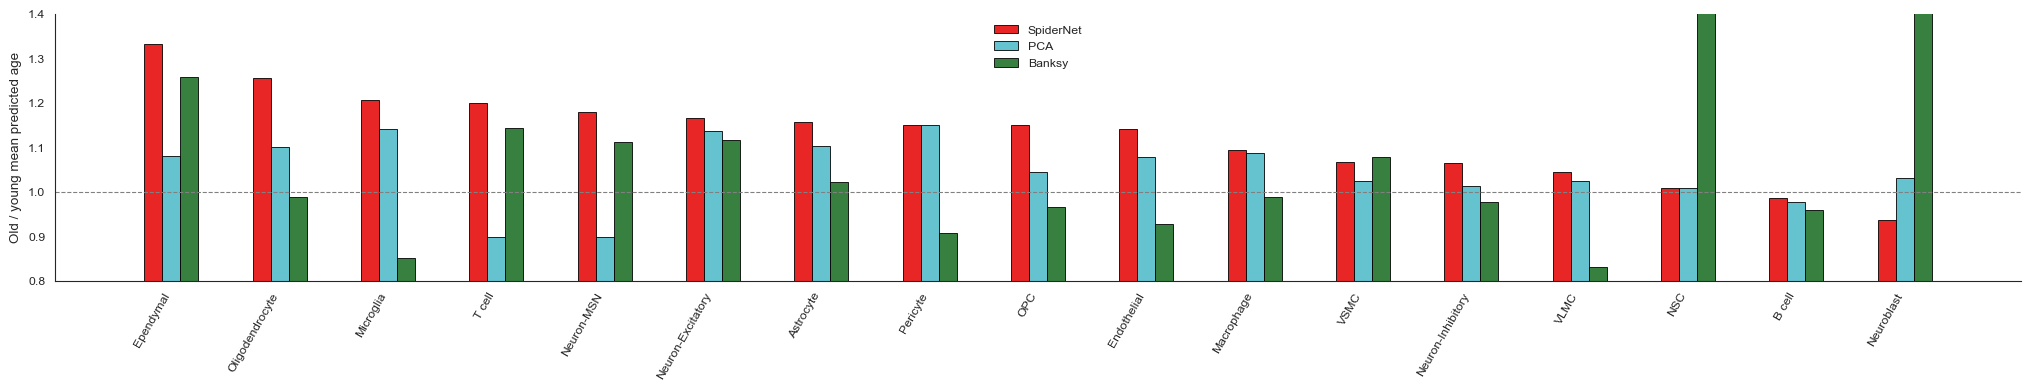

Saved ratio bar plot to: D:\SpiderNet\Results\AgingBrain\AgingBrain_Sagittal\V1\SpiderNet_Result_dim30\Sagittal_Old_vs_Young_ratio_barplot_SpiderNet_vs_PCA_vs_Banksy.pdf


In [10]:
sagittal_results = run_transfer_analysis(
    dataset_label="Sagittal",
    preprocess_fn=lambda: preprocess_sagittal_dataset(
        processed_dir=SAGITTAL_PROCESSED_DATA_DIR,
        run_dirs_obj=sagittal_run_dirs,
    ),
    paths_obj=sagittal_paths,
    run_dirs_obj=sagittal_run_dirs,
    processed_train=processed_train,
    model=model,
    reg_scale_dict=reg_scale_dict,
    reg_scale_exppca_dict=reg_scale_exppca_dict,
    reg_scale_commot_dict=reg_scale_commot_dict,
    reg_scale_banksy_dict=reg_scale_banksy_dict,
    preprocess_cfg=preprocess_cfg,
    old_age_threshold=OLD_AGE_THRESHOLD,
    plot_ymin=0.8,
    ratio_max=1.4,
    reference_processed_data_dir=TRAIN_PROCESSED_DATA_DIR
)


In [11]:
sagittal_results['ratio_df_combined']

,CellType,SpiderNet_Old_vs_Young_ratio,PCA_Old_vs_Young_ratio,Banksy_Old_vs_Young_ratio
0,Astrocyte,1.156585,1.103249,1.023323
1,B cell,0.985693,0.976995,0.959412
2,Endothelial,1.142616,1.079874,0.929436
3,Ependymal,1.332142,1.081869,1.257989
4,Macrophage,1.095355,1.087161,0.988249
5,Microglia,1.207369,1.142122,0.851434
6,NSC,1.008956,1.009855,1.694988
7,Neuroblast,0.936983,1.030913,1.669616
8,Neuron-Excitatory,1.167328,1.136150,1.117576
9,Neuron-Inhibitory,1.066428,1.013670,0.977759



## 7. Transfer to hippocampus

The hippocampus transfer uses the same downstream prediction logic, but the preprocessing step follows the older hippocampus-specific loader that expects the **training gene list** as input.


Using existing processed hippocampus data: D:\SpiderNet\Results\AgingBrain\AgingBrain_Hippocampus\V1\SpiderNet_Result_dim30\SpiderNet_data_pyg_list.pkl
Hippocampus: loaded 6 batches.
Hippocampus: total cells = 27624


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Batch 0: these transfer cell types are not present in the training cell-class space and were left as all-zero one-hot rows: ['Others']
Batch 1: these transfer cell types are not present in the training cell-class space and were left as all-zero one-hot rows: ['Others']
Batch 2: these transfer cell types are not present in the training cell-class space and were left as all-zero one-hot rows: ['Others']
Batch 3: these transfer cell types are not present in the training cell-class space and were left as all-zero one-hot rows: ['Others']
Batch 4: these transfer cell types are not present in the training cell-class space and were left as all-zero one-hot rows: ['Others']
Batch 5: these transfer cell types are not present in the training cell-class space and were left as all-zero one-hot rows: ['Others']
Hippocampus: matched Banksy slice 0 -> Hippocampus_O_1_1_processed_Banksy_cellidentity_lambda0.2.mtx
Hippocampus: matched Banksy slice 1 -> Hippocampus_O_2_1_processed_Banksy_cellidentity_la

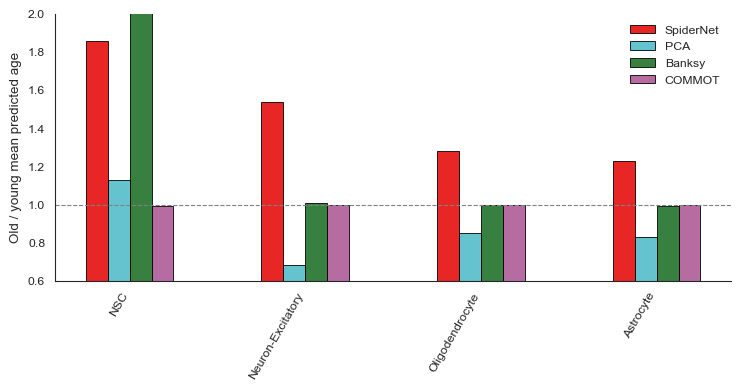

Saved ratio bar plot to: D:\SpiderNet\Results\AgingBrain\AgingBrain_Hippocampus\V1\SpiderNet_Result_dim30\Hippocampus_Old_vs_Young_ratio_barplot_SpiderNet_vs_PCA_vs_Banksy_vs_COMMOT.pdf


In [12]:
hippocampus_results = run_transfer_analysis(
    dataset_label="Hippocampus",
    preprocess_fn=lambda: preprocess_hippocampus_dataset(
        processed_dir=HIPPOCAMPUS_PROCESSED_DATA_DIR,
        run_dirs_obj=hippocampus_run_dirs,
    ),
    paths_obj=hippocampus_paths,
    run_dirs_obj=hippocampus_run_dirs,
    processed_train=processed_train,
    model=model,
    reg_scale_dict=reg_scale_dict,
    reg_scale_exppca_dict=reg_scale_exppca_dict,
    reg_scale_commot_dict=reg_scale_commot_dict,
    reg_scale_banksy_dict=reg_scale_banksy_dict,
    preprocess_cfg=preprocess_cfg,
    old_age_threshold=OLD_AGE_THRESHOLD,
    plot_ymin=0.6,
    ratio_max=2,
    reference_processed_data_dir=TRAIN_PROCESSED_DATA_DIR
)


In [13]:
hippocampus_results['ratio_df_combined']

,CellType,SpiderNet_Old_vs_Young_ratio,PCA_Old_vs_Young_ratio,Banksy_Old_vs_Young_ratio,COMMOT_Old_vs_Young_ratio
0,Astrocyte,1.228939,0.830921,0.995396,1.000080
1,NSC,1.857120,1.131891,14.827501,0.993326
2,Neuron-Excitatory,1.540712,0.682793,1.008335,0.998046
3,Oligodendrocyte,1.281666,0.853555,0.997753,0.999739


## 8. Combined summary table

In [14]:
combined_ratio_summary = pd.concat([
    sagittal_results["ratio_df_combined"].assign(Dataset="Sagittal"),
    hippocampus_results["ratio_df_combined"].assign(Dataset="Hippocampus"),
], axis=0, ignore_index=True)

preferred_columns = [
    "Dataset",
    "CellType",
    "SpiderNet_Old_vs_Young_ratio",
    "PCA_Old_vs_Young_ratio",
    "Banksy_Old_vs_Young_ratio",
    "COMMOT_Old_vs_Young_ratio",
]
combined_ratio_summary = combined_ratio_summary[
    [col for col in preferred_columns if col in combined_ratio_summary.columns]
]

combined_ratio_summary.to_csv(
    train_run_dirs["run_dir"] / "Transfer_old_vs_young_ratio_summary.csv",
    index=False
)

combined_ratio_summary

,Dataset,CellType,SpiderNet_Old_vs_Young_ratio,PCA_Old_vs_Young_ratio,Banksy_Old_vs_Young_ratio,COMMOT_Old_vs_Young_ratio
0,Sagittal,Astrocyte,1.156585,1.103249,1.023323,NaN
1,Sagittal,B cell,0.985693,0.976995,0.959412,NaN
2,Sagittal,Endothelial,1.142616,1.079874,0.929436,NaN
3,Sagittal,Ependymal,1.332142,1.081869,1.257989,NaN
4,Sagittal,Macrophage,1.095355,1.087161,0.988249,NaN
5,Sagittal,Microglia,1.207369,1.142122,0.851434,NaN
6,Sagittal,NSC,1.008956,1.009855,1.694988,NaN
7,Sagittal,Neuroblast,0.936983,1.030913,1.669616,NaN
8,Sagittal,Neuron-Excitatory,1.167328,1.136150,1.117576,NaN
9,Sagittal,Neuron-Inhibitory,1.066428,1.013670,0.977759,NaN
